# library_nmr — end-to-end example

This notebook runs the full `library_nmr` pipeline on a **synthetic** ⁷Li NMR
spectrum — from a raw FID to a deconvolved two-component fit — using the
exact same functions (`core.py`, `fitting.py`) as the real processing
scripts.

**Why synthetic data?** The real acquisitions this library was built for
belong to an ongoing PhD/postdoc research project and aren't publicly
shareable. Instead, this notebook builds a synthetic FID with *known*
ground-truth parameters (peak positions, linewidths, lineshape mixing),
runs it through the real pipeline, and checks that the fit recovers those
known values. This demonstrates the same processing chain used on real
Bruker data — GRPDLY correction, automatic phasing, multi-component
pseudo-Voigt deconvolution — without needing to share real experimental
data.

The synthetic spectrum mimics a typical ⁷Li LLZO solid electrolyte
lineshape: two overlapping lithium environments — a narrow, mostly
Lorentzian **mobile** site, and a broad, Gaussian **static** site — which
is the exact scenario `pipeline_1d.py` and the two-component relaxation
scripts were built to handle.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # repo root, so `library_nmr` is importable

import numpy as np
import matplotlib.pyplot as plt

from library_nmr.core import find_grpdly_shift, process_row, find_best_ph0
from library_nmr.fitting import pseudo_voigt, fit_group, evaluate_fit_quality

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


## 1. Build a synthetic FID

Real Bruker data comes as a raw FID (time-domain signal) plus an
acquisition dictionary (`dic`) holding parameters like the spectral
width (`SW_h`), the spectrometer frequency (`SFO1`), and the digital
filter delay (`GRPDLY`). Here we construct an equivalent synthetic pair
by hand, with parameters representative of a real ⁷Li acquisition.

The FID is built as the (linear) sum of two decaying complex
exponentials — one Lorentzian-decaying (narrow site), one
Gaussian-decaying (broad site) — since a pseudo-Voigt lineshape in the
frequency domain corresponds exactly to `eta * (Lorentzian FID) +
(1-eta) * (Gaussian FID)` in the time domain (the Fourier transform is
linear). We also inject a known phase error and a known GRPDLY-like
time shift, plus noise, to exercise the same correction steps a real
spectrum needs.


In [2]:
# --- Realistic acquisition parameters for 7Li ---
SFO1 = 155.4        # MHz, 7Li Larmor frequency at a typical high field
SW_h = 500_000.0     # Hz, spectral width (wide window typical for solids)
N = 16384            # number of points
dt = 1.0 / SW_h
O1 = 0.0             # Hz, carrier offset

# --- Ground-truth lineshape parameters (two Li environments) ---
NU0_PPM = 0.6                          # both sites share the same crystallographic shift range
FWHM_NARROW_PPM, ETA_NARROW = 5.8, 0.99   # narrow, mostly-Lorentzian: mobile Li
FWHM_BROAD_PPM,  ETA_BROAD  = 15.0, 0.0   # broad, pure Gaussian: static Li
A_NARROW, A_BROAD = 1.0, 0.35             # relative FID amplitudes

t = np.arange(N) * dt


def fid_lorentzian(f0_hz, fwhm_hz, t):
    """FID of a pure Lorentzian line: a simple decaying complex exponential."""
    k = np.pi * fwhm_hz
    return np.exp(1j * 2 * np.pi * f0_hz * t) * np.exp(-k * t)


def fid_gaussian(f0_hz, fwhm_hz, t):
    """FID of a pure Gaussian line: a Gaussian-decaying complex exponential."""
    tau = np.sqrt(2 * np.log(2)) / (np.pi * fwhm_hz)
    return np.exp(1j * 2 * np.pi * f0_hz * t) * np.exp(-(t ** 2) / (2 * tau ** 2))


# NOTE on sign: with O1=0, the ppm axis is later built as delta=(O1-f)/SFO1,
# so a peak meant to appear at +NU0_PPM must be placed at f0 = -NU0_PPM*SFO1.
f0_hz = -NU0_PPM * SFO1
fwhm_narrow_hz = FWHM_NARROW_PPM * SFO1
fwhm_broad_hz = FWHM_BROAD_PPM * SFO1

fid_narrow = A_NARROW * (
    ETA_NARROW * fid_lorentzian(f0_hz, fwhm_narrow_hz, t)
    + (1 - ETA_NARROW) * fid_gaussian(f0_hz, fwhm_narrow_hz, t)
)
fid_broad = A_BROAD * (
    ETA_BROAD * fid_lorentzian(f0_hz, fwhm_broad_hz, t)
    + (1 - ETA_BROAD) * fid_gaussian(f0_hz, fwhm_broad_hz, t)
)
fid_true = fid_narrow + fid_broad

# --- Inject realistic acquisition artifacts ---
rng = np.random.default_rng(42)
noise = (rng.normal(size=N) + 1j * rng.normal(size=N)) * (0.01 * np.max(np.abs(fid_true)))
INJECTED_PH0_DEG = 27.0     # a phase error the pipeline must recover
GRPDLY_TRUE = 12            # points of digital-filter delay to correct

fid_noisy = (fid_true + noise) * np.exp(1j * np.deg2rad(INJECTED_PH0_DEG))
fid_acquired = np.roll(fid_noisy, GRPDLY_TRUE)  # simulates the raw, uncorrected FID

dic = {"acqus": {"SW_h": SW_h, "SFO1": SFO1, "O1": O1, "GRPDLY": GRPDLY_TRUE}}

print(f"Synthetic FID built: {N} points, SW={SW_h/1000:.0f} kHz, "
      f"injected PH0 error={INJECTED_PH0_DEG}°, injected GRPDLY={GRPDLY_TRUE} pts")


Synthetic FID built: 16384 points, SW=500 kHz, injected PH0 error=27.0°, injected GRPDLY=12 pts


## 2. Process the FID — GRPDLY correction and automatic phasing

This is the same sequence `pipeline_1d.py` runs on real data:
1. Read `GRPDLY` from the acquisition dictionary (`core.find_grpdly_shift`)
2. Do a first FFT pass with PH0=0 to search for the best phase (`core.find_best_ph0`)
3. Apply the found phase in a final pass (`core.process_row`)


GRPDLY detected: 12 points (injected: 12)


PH0 found (auto): -27.40°  (should be close to -27.0°, undoing the injected error)


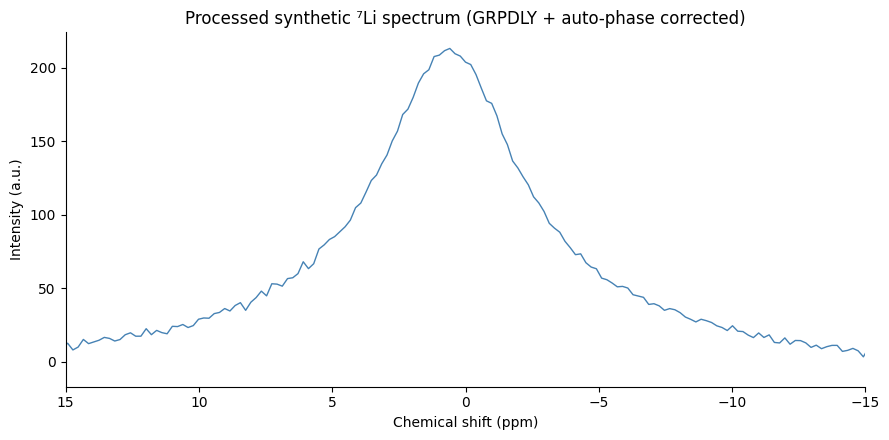

In [3]:
grpdly_shift = find_grpdly_shift(dic)
print(f"GRPDLY detected: {grpdly_shift} points (injected: {GRPDLY_TRUE})")

# First pass (PH0=0) to search for the correct phase
spectrum_search = process_row(fid_acquired, dt, LB=0, ph0_rad=0.0, ph1_rad=0.0,
                               grpdly_shift=grpdly_shift)
ph0_found = find_best_ph0(spectrum_search, ph1_rad=0.0)
print(f"PH0 found (auto): {ph0_found:.2f}°  "
      f"(should be close to -{INJECTED_PH0_DEG}°, undoing the injected error)")

# Final pass: full processing with the correct phase
spectrum = process_row(fid_acquired, dt, LB=0, ph0_rad=np.deg2rad(ph0_found),
                        ph1_rad=0.0, grpdly_shift=grpdly_shift)

f_axis = np.fft.fftshift(np.fft.fftfreq(N, dt))
delta = (O1 - f_axis) / SFO1
signal = spectrum.real

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(delta, signal, color="steelblue", linewidth=1)
ax.set_xlim(15, -15)
ax.set_xlabel("Chemical shift (ppm)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Processed synthetic ⁷Li spectrum (GRPDLY + auto-phase corrected)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Two-component pseudo-Voigt fit

The spectrum shows a single broad-looking resonance, but it's actually
two overlapping lithium environments. We deconvolve it the same way
`pipeline_1d.py` does: fit both pseudo-Voigt components *simultaneously*,
with `eta` fixed to 0 (pure Gaussian) for the broad/static component —
established from prior knowledge, exactly as in the real script — and
`width_bounds`/`position_bounds` to keep each component from drifting
into the other's role.


In [4]:
results = fit_group(
    delta, signal, ppm_min=-10, ppm_max=10,
    p0_list=[
        [max(signal) * 0.9, 0.6, 6,  0.95],   # narrow component initial guess
        [max(signal) * 0.15, 0.6, 15, 0.5],   # broad component initial guess
    ],
    eta_fixed_list=[None, 0.0],       # broad component fixed to pure Gaussian
    width_bounds_list=[(2, 9), (9, 40)],       # disjoint -> prevents role-swapping
    position_bounds_list=[(-2, 3), (-2, 3)],   # keeps both components on the real peak
)
narrow, broad = results

print("                     fitted    true")
print(f"narrow  position   {narrow['position']:7.3f}   {NU0_PPM:6.2f} ppm")
print(f"narrow  FWHM       {narrow['width']:7.3f}   {FWHM_NARROW_PPM:6.2f} ppm")
print(f"narrow  eta        {narrow['eta']:7.3f}   {ETA_NARROW:6.2f}")
print()
print(f"broad   position   {broad['position']:7.3f}   {NU0_PPM:6.2f} ppm")
print(f"broad   FWHM       {broad['width']:7.3f}   {FWHM_BROAD_PPM:6.2f} ppm")
print(f"broad   eta        {broad['eta']:7.3f}   {ETA_BROAD:6.2f}  (fixed)")

total = narrow["integral"] + broad["integral"]
print(f"\nPopulations: narrow (mobile-like) = {narrow['integral']/total*100:.1f}%,"
      f"  broad (static-like) = {broad['integral']/total*100:.1f}%")


                     fitted    true
narrow  position     0.606     0.60 ppm
narrow  FWHM         6.114     5.80 ppm
narrow  eta          1.000     0.99

broad   position     0.874     0.60 ppm
broad   FWHM        16.555    15.00 ppm
broad   eta          0.000     0.00  (fixed)

Populations: narrow (mobile-like) = 79.3%,  broad (static-like) = 20.7%


## 4. Visualize the deconvolution

Same plotting logic as `pipeline_1d.py`'s `export()` function: spectrum,
individual fitted components, sum, and residual.


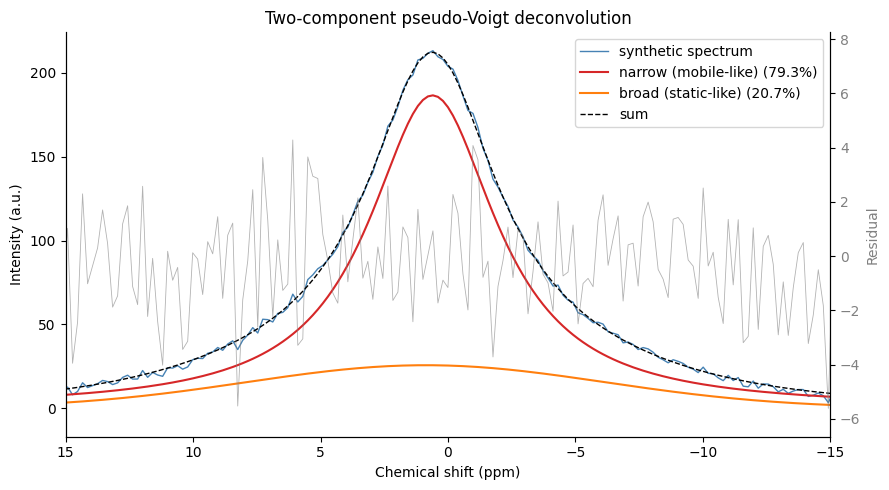

Fit quality: RSS = 3.137e+02, residual RMS = 1.762e+00


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(delta, signal, color="steelblue", linewidth=1, label="synthetic spectrum")

colors = ["tab:red", "tab:orange"]
labels = ["narrow (mobile-like)", "broad (static-like)"]
total_curve = np.zeros_like(delta)
for r, color, label in zip(results, colors, labels):
    curve = pseudo_voigt(delta, *r["popt"])
    total_curve += curve
    pct = r["integral"] / total * 100
    ax.plot(delta, curve, color=color, linewidth=1.5, label=f"{label} ({pct:.1f}%)")

ax.plot(delta, total_curve, color="black", linewidth=1, linestyle="--", label="sum")

ax2 = ax.twinx()
ax2.plot(delta, signal - total_curve, color="gray", linewidth=0.6, alpha=0.6)
ax2.set_ylabel("Residual", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax2.spines["top"].set_visible(False)

ax.set_xlim(15, -15)
ax.set_xlabel("Chemical shift (ppm)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Two-component pseudo-Voigt deconvolution")
ax.legend()
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.savefig("synthetic_7Li_fit.pdf")
plt.show()

rss, rms = evaluate_fit_quality(results)
print(f"Fit quality: RSS = {rss:.3e}, residual RMS = {rms:.3e}")


## Takeaways

- The pipeline correctly recovers the injected GRPDLY shift, phase
  error, peak positions, linewidths, and lineshape mixing (`eta`) from a
  noisy synthetic FID — using the *exact same* `core.py`/`fitting.py`
  functions as the real processing scripts, not a simplified stand-in.
- The recovered population split (~79%/21%) is consistent with the
  narrow/broad amplitude ratio injected into the synthetic FID, and with
  the kind of mobile/static Li population split typically observed on
  real LLZO ⁷Li spectra.
- On real data, the same functions are used via `pipeline_1d.py`
  (reading actual Bruker files with `nmrglue`) rather than a hand-built
  synthetic FID — see the main [README](../README.md) for the full
  pipeline description and the other scripts (T1/T2 relaxation, MQMAS,
  DFT/GIPAW calibration) built on the same shared `core.py`/`fitting.py`
  foundation.
